Загрузка данных и первичный анализ

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    StackingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)
from sklearn.inspection import permutation_importance

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

artifacts_dir = Path('artifacts')
figures_dir = artifacts_dir / 'figures'

In [5]:
df = pd.read_csv('S06-hw-dataset-02.csv')

print(f"Размер датасета: {df.shape}")
print(f"\nПервые строки:")
df.head()

Размер датасета: (18000, 39)

Первые строки:


,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
0,1,-0.149235,-2.826966,-0.522901,-4.198449,1.364943,0.815043,-1.195518,-1.932232,2.396353,...,-0.159323,0.448015,0.572745,0.149916,0.878392,-0.679733,1.412751,0.421883,9.217167,1
1,2,-1.966180,-4.877542,0.268367,-9.607791,0.097149,1.347185,-3.872575,-0.395117,1.710068,...,-0.389212,1.383794,0.169876,0.043969,-0.963545,1.006643,-2.488690,9.590124,24.772826,0
2,3,-0.555964,-0.999920,0.209673,-14.119498,-1.808950,-0.006222,-4.651108,0.911944,-0.289037,...,-1.383970,3.044321,-0.182864,1.425649,-8.418598,-4.629754,-0.439798,0.555919,41.800517,0
3,4,-2.049199,-5.600713,-1.664677,-6.263893,-5.224455,0.848351,1.407210,-0.542080,0.119102,...,-2.713080,2.762637,-0.520796,-0.142455,1.668338,2.292810,-10.744916,11.476977,65.315860,0
4,5,-0.220556,4.889479,-2.235840,6.450046,0.774389,-2.382625,2.584816,4.211856,-0.317889,...,-1.302872,2.478862,1.528610,1.098131,3.547087,2.517757,-9.364106,-1.078404,93.017870,0


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 39 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       18000 non-null  int64  
 1   f01      18000 non-null  float64
 2   f02      18000 non-null  float64
 3   f03      18000 non-null  float64
 4   f04      18000 non-null  float64
 5   f05      18000 non-null  float64
 6   f06      18000 non-null  float64
 7   f07      18000 non-null  float64
 8   f08      18000 non-null  float64
 9   f09      18000 non-null  float64
 10  f10      18000 non-null  float64
 11  f11      18000 non-null  float64
 12  f12      18000 non-null  float64
 13  f13      18000 non-null  float64
 14  f14      18000 non-null  float64
 15  f15      18000 non-null  float64
 16  f16      18000 non-null  float64
 17  f17      18000 non-null  float64
 18  f18      18000 non-null  float64
 19  f19      18000 non-null  float64
 20  f20      18000 non-null  float64
 21  f21      180

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,...,f29,f30,f31,f32,f33,f34,f35,x_int_1,x_int_2,target
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,...,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,1.800000e+04,18000.000000
mean,9000.500000,-0.418555,0.614251,0.004559,0.059000,0.405086,0.012123,-0.283473,-0.266880,0.255107,...,-0.139825,0.108568,0.007238,0.000904,-0.716862,-0.274520,0.344991,1.517339,2.576221e+01,0.262611
std,5196.296758,2.178005,3.926778,1.000134,5.713672,2.497581,0.987226,2.193891,2.081431,2.225776,...,2.148834,2.234315,0.997861,1.002115,3.913704,2.482890,4.927315,10.630850,5.423748e+01,0.440065
min,1.000000,-10.014698,-15.510323,-4.031762,-23.663256,-12.289308,-3.741536,-9.591425,-8.293319,-13.655742,...,-8.171469,-9.214171,-3.937091,-3.963063,-19.389908,-10.031559,-20.768452,-107.788145,1.895059e-07,0.000000
25%,4500.750000,-1.866134,-2.048192,-0.673127,-3.544964,-1.153000,-0.653090,-1.743214,-1.688121,-1.177480,...,-1.589638,-1.369266,-0.663023,-0.684164,-3.286842,-1.897893,-2.752685,-2.018750,1.226029e+00,0.000000
50%,9000.500000,-0.465100,0.600291,0.003581,0.072826,0.485625,0.018765,-0.251263,-0.302463,0.350739,...,-0.204785,0.158715,0.001912,-0.003157,-0.618472,-0.339901,0.573153,0.318011,6.581865e+00,0.000000
75%,13500.250000,0.966393,3.229850,0.671390,3.689490,2.075739,0.689304,1.195481,1.109589,1.764113,...,1.254595,1.600671,0.677296,0.676558,1.948803,1.314163,3.649794,4.212111,2.576847e+01,1.000000
max,18000.000000,9.589975,15.417329,3.817025,26.815691,10.665184,3.528280,7.794627,8.892834,8.699629,...,9.290667,8.794320,4.341030,3.781380,14.065595,10.639974,20.226291,94.891804,1.103449e+03,1.000000


Пропуски в данных:
Пропусков нет

Распределение целевой переменной:
target
0    0.737389
1    0.262611
Name: proportion, dtype: float64

Абсолютные значения:
target
0    13273
1     4727
Name: count, dtype: int64


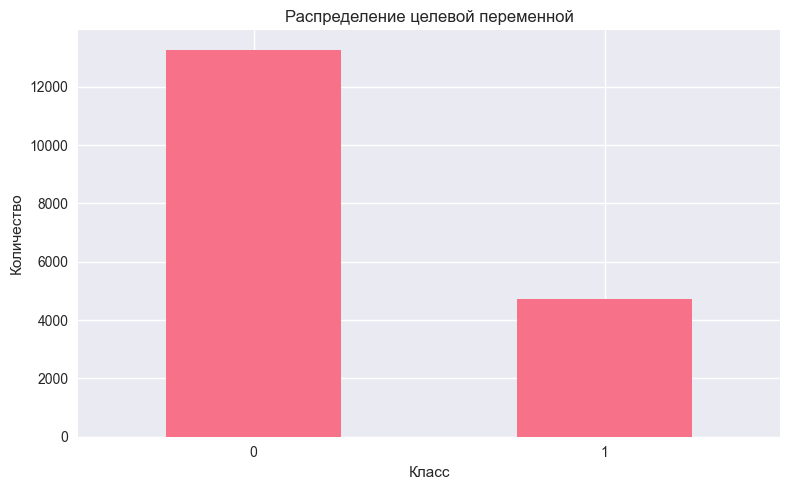

In [ ]:
print("Пропуски в данных:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Пропусков нет")

# Распределение целевой переменной
print("\n" + "="*50)
print("Распределение целевой переменной:")
target_dist = df['target'].value_counts(normalize=True)
print(target_dist)
print(f"\nАбсолютные значения:")
print(df['target'].value_counts())

# Визуализация распределения
plt.figure(figsize=(8, 5))
df['target'].value_counts().plot(kind='bar')
plt.title('Распределение целевой переменной')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(figures_dir / 'target_distribution.png', dpi=150)
plt.show()

In [7]:
# Определение признаков и целевой переменной
X = df.drop(['id', 'target'], axis=1)
y = df['target']

print(f"Количество признаков: {X.shape[1]}")
print(f"Типы признаков:")
print(X.dtypes.value_counts())

# Проверка категориально-подобных признаков
print("\nКатегориально-подобные признаки (x_int_1, x_int_2):")
if 'x_int_1' in X.columns:
    print(f"x_int_1 уникальных значений: {X['x_int_1'].nunique()}")
    print(f"x_int_1 значения: {sorted(X['x_int_1'].unique())}")
if 'x_int_2' in X.columns:
    print(f"x_int_2 уникальных значений: {X['x_int_2'].nunique()}")
    print(f"x_int_2 значения: {sorted(X['x_int_2'].unique())}")

Количество признаков: 37
Типы признаков:
float64    37
Name: count, dtype: int64

Категориально-подобные признаки (x_int_1, x_int_2):
x_int_1 уникальных значений: 18000
x_int_1 значения: [np.float64(-107.78814479449323), np.float64(-85.73802091084193), np.float64(-77.96586145805165), np.float64(-75.22099335067706), np.float64(-71.67245243520595), np.float64(-68.91230736416372), np.float64(-61.384936046947445), np.float64(-59.19521757296247), np.float64(-58.767819000833015), np.float64(-58.67161835907745), np.float64(-57.50774677077656), np.float64(-57.298993015763095), np.float64(-56.546124866176086), np.float64(-55.5693876948079), np.float64(-55.21318631539779), np.float64(-55.06795637220205), np.float64(-54.91979347342418), np.float64(-53.801250429029146), np.float64(-52.37775537912122), np.float64(-52.03100397040652), np.float64(-52.00769516236619), np.float64(-51.53750881548261), np.float64(-51.22985814233275), np.float64(-50.7568459107382), np.float64(-50.61374446999189), np.float

Сплит и воспроизводимость

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение классов в train:")
print(y_train.value_counts(normalize=True))
print(f"\nРаспределение классов в test:")
print(y_test.value_counts(normalize=True))


Размер обучающей выборки: (14400, 37)
Размер тестовой выборки: (3600, 37)

Распределение классов в train:
target
0    0.737361
1    0.262639
Name: proportion, dtype: float64

Распределение классов в test:
target
0    0.7375
1    0.2625
Name: proportion, dtype: float64


Комментарий о воспроизводимости:

- Фиксированный `random_state=42` обеспечивает воспроизводимость результатов: при каждом запуске данные будут разделены одинаковым образом.
- `stratify=y` гарантирует, что пропорции классов в train и test будут одинаковыми, что важно для корректной оценки модели, особенно при дисбалансе классов.


Baseline

In [9]:
# Словарь для хранения результатов всех моделей
results = {}

# 1. DummyClassifier (baseline)
print("="*60)
print("1. DummyClassifier (baseline)")
print("="*60)

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
y_pred_proba_dummy = dummy.predict_proba(X_test)[:, 1]

dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
dummy_f1 = f1_score(y_test, y_pred_dummy)
dummy_roc_auc = roc_auc_score(y_test, y_pred_proba_dummy)

results['DummyClassifier'] = {
    'accuracy': dummy_accuracy,
    'f1': dummy_f1,
    'roc_auc': dummy_roc_auc
}

print(f"Accuracy: {dummy_accuracy:.4f}")
print(f"F1: {dummy_f1:.4f}")
print(f"ROC-AUC: {dummy_roc_auc:.4f}")
print(f"\nСтратегия: {dummy.strategy}")
print(f"Всегда предсказывает класс: {dummy.predict(X_test[:1])[0]}")


1. DummyClassifier (baseline)
Accuracy: 0.7375
F1: 0.0000
ROC-AUC: 0.5000

Стратегия: most_frequent
Всегда предсказывает класс: 0


In [10]:
# 2. LogisticRegression (baseline из S05)
print("\n" + "="*60)
print("2. LogisticRegression (baseline из S05)")
print("="*60)

logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipe.fit(X_train, y_train)
y_pred_logreg = logreg_pipe.predict(X_test)
y_pred_proba_logreg = logreg_pipe.predict_proba(X_test)[:, 1]

logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
logreg_f1 = f1_score(y_test, y_pred_logreg)
logreg_roc_auc = roc_auc_score(y_test, y_pred_proba_logreg)

results['LogisticRegression'] = {
    'accuracy': logreg_accuracy,
    'f1': logreg_f1,
    'roc_auc': logreg_roc_auc
}

print(f"Accuracy: {logreg_accuracy:.4f}")
print(f"F1: {logreg_f1:.4f}")
print(f"ROC-AUC: {logreg_roc_auc:.4f}")



2. LogisticRegression (baseline из S05)
Accuracy: 0.8119
F1: 0.5607
ROC-AUC: 0.7977


DecisionTreeClassifier

In [ ]:
print("="*60)
print("3. DecisionTreeClassifier")
print("="*60)

# Подбор гиперпараметров через GridSearchCV
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'min_samples_split': [2, 5, 10]
}

dt = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(
    dt, dt_param_grid, 
    cv=5, 
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print(f"\nЛучшие параметры: {dt_grid.best_params_}")
print(f"Лучший CV score (ROC-AUC): {dt_grid.best_score_:.4f}")

# Оценка на тестовой выборке
y_pred_dt = dt_grid.predict(X_test)
y_pred_proba_dt = dt_grid.predict_proba(X_test)[:, 1]

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_pred_proba_dt)

results['DecisionTreeClassifier'] = {
    'accuracy': dt_accuracy,
    'f1': dt_f1,
    'roc_auc': dt_roc_auc,
    'best_params': dt_grid.best_params_,
    'best_cv_score': dt_grid.best_score_
}

print(f"\nРезультаты на тестовой выборке:")
print(f"Accuracy: {dt_accuracy:.4f}")
print(f"F1: {dt_f1:.4f}")
print(f"ROC-AUC: {dt_roc_auc:.4f}")

3. DecisionTreeClassifier
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}
Лучший CV score (ROC-AUC): 0.8290

Результаты на тестовой выборке:
Accuracy: 0.8383
F1: 0.6576
ROC-AUC: 0.8371


RandomForestClassifier

In [12]:
print("\n" + "="*60)
print("4. RandomForestClassifier")
print("="*60)

# Подбор гиперпараметров
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(
    rf, rf_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"\nЛучшие параметры: {rf_grid.best_params_}")
print(f"Лучший CV score (ROC-AUC): {rf_grid.best_score_:.4f}")

# Оценка на тестовой выборке
y_pred_rf = rf_grid.predict(X_test)
y_pred_proba_rf = rf_grid.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

results['RandomForestClassifier'] = {
    'accuracy': rf_accuracy,
    'f1': rf_f1,
    'roc_auc': rf_roc_auc,
    'best_params': rf_grid.best_params_,
    'best_cv_score': rf_grid.best_score_
}

print(f"\nРезультаты на тестовой выборке:")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"F1: {rf_f1:.4f}")
print(f"ROC-AUC: {rf_roc_auc:.4f}")


4. RandomForestClassifier
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Лучший CV score (ROC-AUC): 0.9285

Результаты на тестовой выборке:
Accuracy: 0.8908
F1: 0.7579
ROC-AUC: 0.9281


GradientBoostingClassifier

In [13]:
print("\n" + "="*60)
print("5. GradientBoostingClassifier")
print("="*60)

# Подбор гиперпараметров
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7]
}

gb = GradientBoostingClassifier(random_state=42)
gb_grid = GridSearchCV(
    gb, gb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print(f"\nЛучшие параметры: {gb_grid.best_params_}")
print(f"Лучший CV score (ROC-AUC): {gb_grid.best_score_:.4f}")

# Оценка на тестовой выборке
y_pred_gb = gb_grid.predict(X_test)
y_pred_proba_gb = gb_grid.predict_proba(X_test)[:, 1]

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_roc_auc = roc_auc_score(y_test, y_pred_proba_gb)

results['GradientBoostingClassifier'] = {
    'accuracy': gb_accuracy,
    'f1': gb_f1,
    'roc_auc': gb_roc_auc,
    'best_params': gb_grid.best_params_,
    'best_cv_score': gb_grid.best_score_
}

print(f"\nРезультаты на тестовой выборке:")
print(f"Accuracy: {gb_accuracy:.4f}")
print(f"F1: {gb_f1:.4f}")
print(f"ROC-AUC: {gb_roc_auc:.4f}")


5. GradientBoostingClassifier
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Лучший CV score (ROC-AUC): 0.9318

Результаты на тестовой выборке:
Accuracy: 0.9128
F1: 0.8200
ROC-AUC: 0.9338


StackingClassifier

In [14]:
print("\n" + "="*60)
print("6. StackingClassifier (опционально)")
print("="*60)

# Базовые модели
base_models = [
    ('rf', rf_grid.best_estimator_),
    ('gb', gb_grid.best_estimator_),
    ('logreg', logreg_pipe)
]

# Метамодель
meta_model = LogisticRegression(random_state=42, max_iter=1000)

# Stacking с CV-логикой (по умолчанию использует 5-fold CV)
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

stacking.fit(X_train, y_train)
y_pred_stacking = stacking.predict(X_test)
y_pred_proba_stacking = stacking.predict_proba(X_test)[:, 1]

stacking_accuracy = accuracy_score(y_test, y_pred_stacking)
stacking_f1 = f1_score(y_test, y_pred_stacking)
stacking_roc_auc = roc_auc_score(y_test, y_pred_proba_stacking)

results['StackingClassifier'] = {
    'accuracy': stacking_accuracy,
    'f1': stacking_f1,
    'roc_auc': stacking_roc_auc
}

print(f"Результаты на тестовой выборке:")
print(f"Accuracy: {stacking_accuracy:.4f}")
print(f"F1: {stacking_f1:.4f}")
print(f"ROC-AUC: {stacking_roc_auc:.4f}")


6. StackingClassifier (опционально)
Результаты на тестовой выборке:
Accuracy: 0.9147
F1: 0.8276
ROC-AUC: 0.9345


Метрики качества и визуализация

In [15]:
# Сводная таблица результатов
print("="*60)
print("Сводная таблица результатов всех моделей")
print("="*60)

results_df = pd.DataFrame(results).T
# Убираем вложенные словари для отображения
results_display = results_df[['accuracy', 'f1', 'roc_auc']].copy()
print("\n" + results_display.to_string())

# Сохранение метрик в JSON
metrics_test = {}
for model_name, metrics in results.items():
    metrics_test[model_name] = {
        'accuracy': float(metrics['accuracy']),
        'f1': float(metrics['f1']),
        'roc_auc': float(metrics['roc_auc'])
    }

with open(artifacts_dir / 'metrics_test.json', 'w') as f:
    json.dump(metrics_test, f, indent=2)

print("\n\nМетрики сохранены в artifacts/metrics_test.json")

Сводная таблица результатов всех моделей

                            accuracy        f1   roc_auc
DummyClassifier               0.7375       0.0       0.5
LogisticRegression          0.811944  0.560675  0.797691
DecisionTreeClassifier      0.838333  0.657647  0.837103
RandomForestClassifier      0.890833  0.757856  0.928072
GradientBoostingClassifier  0.912778  0.819954  0.933839
StackingClassifier          0.914722  0.827625  0.934507


Метрики сохранены в artifacts/metrics_test.json


In [16]:
# Сохранение лучших параметров и CV-scores
search_summaries = {}
for model_name, metrics in results.items():
    if 'best_params' in metrics:
        search_summaries[model_name] = {
            'best_params': {k: (int(v) if isinstance(v, (np.integer, np.int64)) else v) 
                          for k, v in metrics['best_params'].items()},
            'best_cv_score': float(metrics['best_cv_score'])
        }

with open(artifacts_dir / 'search_summaries.json', 'w') as f:
    json.dump(search_summaries, f, indent=2)

print("Лучшие параметры сохранены в artifacts/search_summaries.json")
print("\n" + json.dumps(search_summaries, indent=2))

Лучшие параметры сохранены в artifacts/search_summaries.json

{
  "DecisionTreeClassifier": {
    "best_params": {
      "max_depth": 10,
      "min_samples_leaf": 10,
      "min_samples_split": 2
    },
    "best_cv_score": 0.8289624724042927
  },
  "RandomForestClassifier": {
    "best_params": {
      "max_depth": null,
      "max_features": "sqrt",
      "min_samples_leaf": 1,
      "n_estimators": 200
    },
    "best_cv_score": 0.9284960349067773
  },
  "GradientBoostingClassifier": {
    "best_params": {
      "learning_rate": 0.1,
      "max_depth": 7,
      "n_estimators": 200
    },
    "best_cv_score": 0.9318336721263967
  }
}


In [17]:
# Определение лучшей модели по ROC-AUC
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
best_model_score = results[best_model_name]['roc_auc']

print(f"Лучшая модель: {best_model_name}")
print(f"ROC-AUC: {best_model_score:.4f}")

# Сохранение лучшей модели
if best_model_name == 'DummyClassifier':
    best_model = dummy
elif best_model_name == 'LogisticRegression':
    best_model = logreg_pipe
elif best_model_name == 'DecisionTreeClassifier':
    best_model = dt_grid.best_estimator_
elif best_model_name == 'RandomForestClassifier':
    best_model = rf_grid.best_estimator_
elif best_model_name == 'GradientBoostingClassifier':
    best_model = gb_grid.best_estimator_
elif best_model_name == 'StackingClassifier':
    best_model = stacking

joblib.dump(best_model, artifacts_dir / 'best_model.joblib')

# Сохранение метаданных лучшей модели
best_model_meta = {
    'model_name': best_model_name,
    'metrics': metrics_test[best_model_name],
    'best_params': search_summaries.get(best_model_name, {}).get('best_params', None),
    'best_cv_score': search_summaries.get(best_model_name, {}).get('best_cv_score', None)
}

with open(artifacts_dir / 'best_model_meta.json', 'w') as f:
    json.dump(best_model_meta, f, indent=2)

print(f"\nЛучшая модель сохранена в artifacts/best_model.joblib")
print(f"Метаданные сохранены в artifacts/best_model_meta.json")

Лучшая модель: StackingClassifier
ROC-AUC: 0.9345

Лучшая модель сохранена в artifacts/best_model.joblib
Метаданные сохранены в artifacts/best_model_meta.json


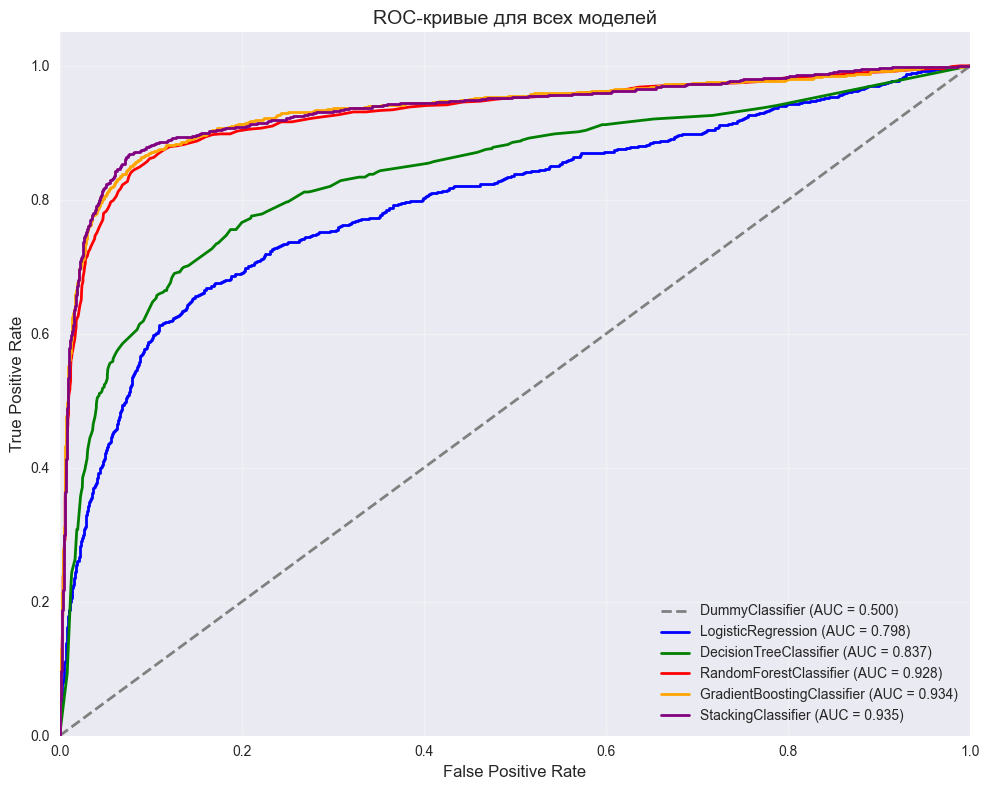

In [19]:
# ROC-кривые для всех моделей
plt.figure(figsize=(10, 8))

models_to_plot = {
    'DummyClassifier': (y_pred_proba_dummy, 'gray', '--'),
    'LogisticRegression': (y_pred_proba_logreg, 'blue', '-'),
    'DecisionTreeClassifier': (y_pred_proba_dt, 'green', '-'),
    'RandomForestClassifier': (y_pred_proba_rf, 'red', '-'),
    'GradientBoostingClassifier': (y_pred_proba_gb, 'orange', '-'),
}

if 'StackingClassifier' in results:
    models_to_plot['StackingClassifier'] = (y_pred_proba_stacking, 'purple', '-')

for model_name, (y_proba, color, linestyle) in models_to_plot.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, color=color, linestyle=linestyle, lw=2, 
             label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые для всех моделей', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'roc_curves.png', dpi=150)
plt.show()

Интерпретация лучшей модели

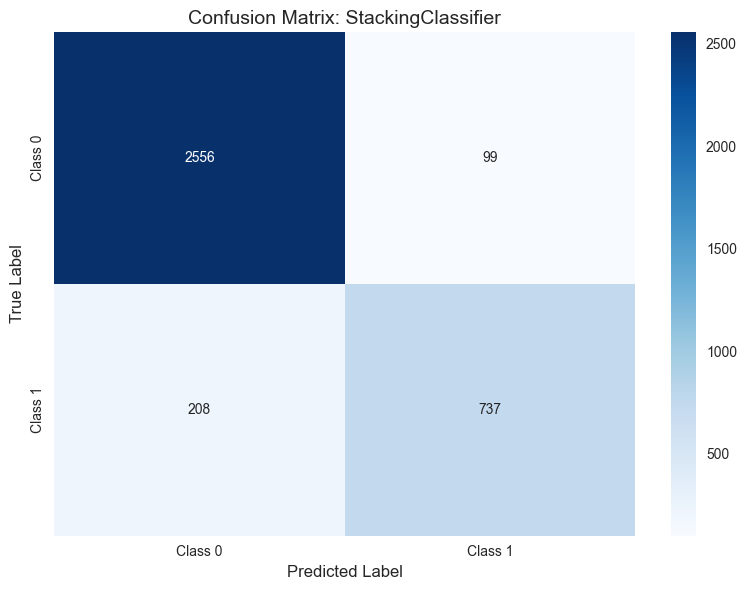


Confusion Matrix для StackingClassifier:
[[2556   99]
 [ 208  737]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2655
           1       0.88      0.78      0.83       945

    accuracy                           0.91      3600
   macro avg       0.90      0.87      0.89      3600
weighted avg       0.91      0.91      0.91      3600



In [20]:
# Confusion Matrix для лучшей модели
if best_model_name == 'DummyClassifier':
    y_pred_best = y_pred_dummy
elif best_model_name == 'LogisticRegression':
    y_pred_best = y_pred_logreg
elif best_model_name == 'DecisionTreeClassifier':
    y_pred_best = y_pred_dt
elif best_model_name == 'RandomForestClassifier':
    y_pred_best = y_pred_rf
elif best_model_name == 'GradientBoostingClassifier':
    y_pred_best = y_pred_gb
elif best_model_name == 'StackingClassifier':
    y_pred_best = y_pred_stacking

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title(f'Confusion Matrix: {best_model_name}', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(figures_dir / 'confusion_matrix.png', dpi=150)
plt.show()

print(f"\nConfusion Matrix для {best_model_name}:")
print(cm)
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best))



Permutation Importance для StackingClassifier

Топ-15 наиболее важных признаков:
feature  importance_mean  importance_std
    f16         0.056349        0.003286
    f01         0.021896        0.002063
    f19         0.013507        0.001825
    f07         0.012394        0.001582
    f15         0.009836        0.001277
    f08         0.009697        0.001003
    f12         0.009302        0.000745
    f30         0.008724        0.000810
    f18         0.008360        0.000750
    f29         0.007975        0.001444
    f23         0.007665        0.001704
    f13         0.007351        0.001061
    f05         0.006881        0.000907
    f34         0.006129        0.000970
    f33         0.004934        0.000626


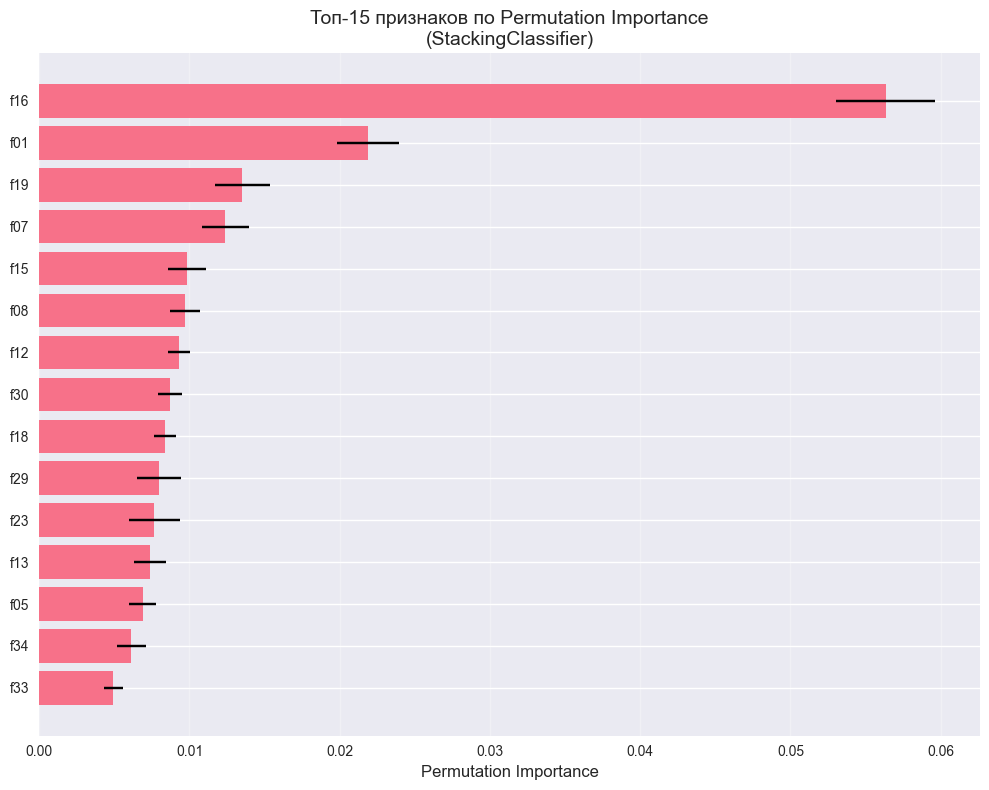


Полные результаты importance сохранены в artifacts/permutation_importance.csv


In [21]:
# Permutation Importance для лучшей модели
print(f"\n" + "="*60)
print(f"Permutation Importance для {best_model_name}")
print("="*60)

# Вычисление permutation importance
perm_importance = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

# Создание DataFrame с результатами
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

# Топ-15 признаков
top_n = 15
top_features = importance_df.head(top_n)

print(f"\nТоп-{top_n} наиболее важных признаков:")
print(top_features.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 8))
plt.barh(range(len(top_features)), top_features['importance_mean'], 
         xerr=top_features['importance_std'], capsize=3)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Permutation Importance', fontsize=12)
plt.title(f'Топ-{top_n} признаков по Permutation Importance\n({best_model_name})', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(figures_dir / 'permutation_importance.png', dpi=150)
plt.show()

# Сохранение importance в CSV
importance_df.to_csv(artifacts_dir / 'permutation_importance.csv', index=False)
print(f"\nПолные результаты importance сохранены в artifacts/permutation_importance.csv")

Анализ устойчивости

Анализ устойчивости моделей

RandomForestClassifier:
  ROC-AUC: 0.9286 ± 0.0040
  Диапазон: [0.9248, 0.9361]

GradientBoostingClassifier:
  ROC-AUC: 0.9324 ± 0.0032
  Диапазон: [0.9278, 0.9369]


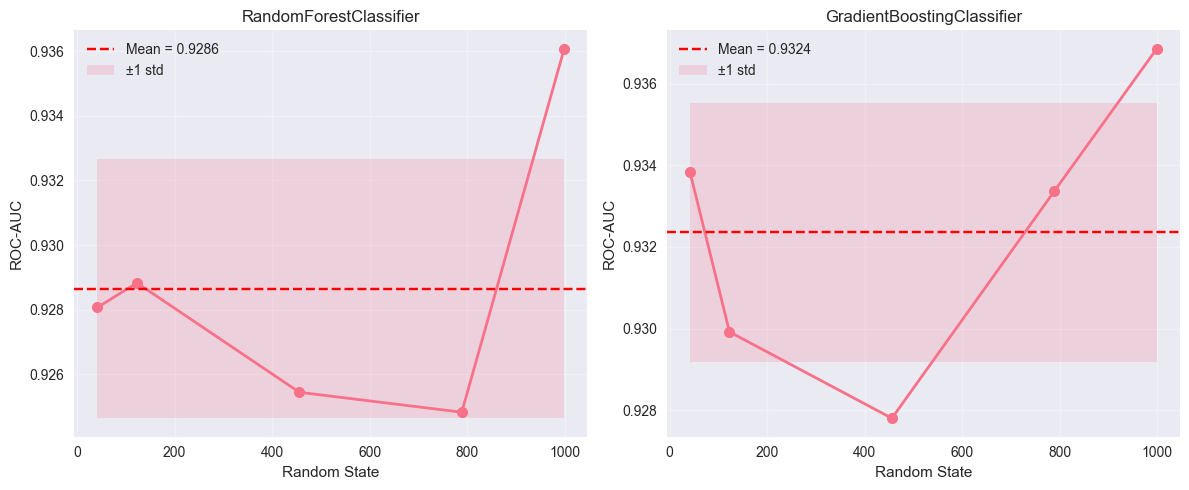


Анализ устойчивости завершен.


In [22]:
# Проверка устойчивости на разных random_state
print("="*60)
print("Анализ устойчивости моделей")
print("="*60)

random_states = [42, 123, 456, 789, 999]
stability_results = {}

# Тестируем RandomForest и GradientBoosting
for model_name in ['RandomForestClassifier', 'GradientBoostingClassifier']:
    roc_aucs = []
    
    for rs in random_states:
        # Пересоздаем train/test split
        X_train_rs, X_test_rs, y_train_rs, y_test_rs = train_test_split(
            X, y, test_size=0.2, random_state=rs, stratify=y
        )
        
        # Обучаем модель с лучшими параметрами
        if model_name == 'RandomForestClassifier':
            model = RandomForestClassifier(
                **rf_grid.best_params_,
                random_state=rs,
                n_jobs=-1
            )
        else:  # GradientBoostingClassifier
            model = GradientBoostingClassifier(
                **gb_grid.best_params_,
                random_state=rs
            )
        
        model.fit(X_train_rs, y_train_rs)
        y_pred_proba = model.predict_proba(X_test_rs)[:, 1]
        roc_auc = roc_auc_score(y_test_rs, y_pred_proba)
        roc_aucs.append(roc_auc)
    
    stability_results[model_name] = {
        'roc_auc_mean': np.mean(roc_aucs),
        'roc_auc_std': np.std(roc_aucs),
        'roc_auc_min': np.min(roc_aucs),
        'roc_auc_max': np.max(roc_aucs),
        'values': roc_aucs
    }
    
    print(f"\n{model_name}:")
    print(f"  ROC-AUC: {np.mean(roc_aucs):.4f} ± {np.std(roc_aucs):.4f}")
    print(f"  Диапазон: [{np.min(roc_aucs):.4f}, {np.max(roc_aucs):.4f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, (model_name, stats) in enumerate(stability_results.items()):
    axes[idx].plot(random_states, stats['values'], 'o-', linewidth=2, markersize=8)
    axes[idx].axhline(y=stats['roc_auc_mean'], color='r', linestyle='--', 
                     label=f"Mean = {stats['roc_auc_mean']:.4f}")
    axes[idx].fill_between(random_states, 
                          stats['roc_auc_mean'] - stats['roc_auc_std'],
                          stats['roc_auc_mean'] + stats['roc_auc_std'],
                          alpha=0.2, label=f"±1 std")
    axes[idx].set_xlabel('Random State', fontsize=11)
    axes[idx].set_ylabel('ROC-AUC', fontsize=11)
    axes[idx].set_title(model_name, fontsize=12)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'stability_analysis.png', dpi=150)
plt.show()

print("\nАнализ устойчивости завершен.")

In [23]:
print("="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*60)

print("\n1. Лучшая модель:", best_model_name)
print(f"   ROC-AUC: {best_model_score:.4f}")
print(f"   Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"   F1: {results[best_model_name]['f1']:.4f}")

print("\n2. Сравнение всех моделей:")
print(results_display.to_string())

print("\n3. Все артефакты сохранены в папке artifacts/")
print("   - metrics_test.json")
print("   - search_summaries.json")
print("   - best_model.joblib")
print("   - best_model_meta.json")
print("   - figures/ (графики)")

print("\n" + "="*60)

ИТОГОВЫЕ РЕЗУЛЬТАТЫ

1. Лучшая модель: StackingClassifier
   ROC-AUC: 0.9345
   Accuracy: 0.9147
   F1: 0.8276

2. Сравнение всех моделей:
                            accuracy        f1   roc_auc
DummyClassifier               0.7375       0.0       0.5
LogisticRegression          0.811944  0.560675  0.797691
DecisionTreeClassifier      0.838333  0.657647  0.837103
RandomForestClassifier      0.890833  0.757856  0.928072
GradientBoostingClassifier  0.912778  0.819954  0.933839
StackingClassifier          0.914722  0.827625  0.934507

3. Все артефакты сохранены в папке artifacts/
   - metrics_test.json
   - search_summaries.json
   - best_model.joblib
   - best_model_meta.json
   - figures/ (графики)

